In [1]:
import sys
import os
import logging
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ==============================================================================
# CÉLULA 1: SETUP E CONFIGURAÇÕES INICIAIS
# ==============================================================================

# 1. Configuração do Diretório (Garante conexão com o Drive se rodar no Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    caminho_projeto = '/content/drive/MyDrive/1) PESQUISA/ESALQ Data Science/tcc/tema_classificacao_queda_arvore/git/tcc_risco_queda_v-pub'
    sys.path.append(caminho_projeto)
    os.chdir(caminho_projeto)
    print("✅ Diretório Colab configurado:", os.getcwd())
except ImportError:
    # Se estiver rodando localmente (não no Colab)
    print("✅ Rodando em ambiente local:", os.getcwd())

Mounted at /content/drive
✅ Diretório Colab configurado: /content/drive/MyDrive/1) PESQUISA/ESALQ Data Science/tcc/tema_classificacao_queda_arvore/git/tcc_risco_queda_v-pub


In [11]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

master = pd.read_parquet('data/processed/00_dataset_queda_MASTER.parquet')
master.head()

master.info()
master.columns

Index(['logradouro_id', 'segmento_id', 'via_extensao_km',
       'via_arvores_contagem', 'via_calcada_largura_min',
       'via_calcada_declinacao_max', 'via_icc_confinamento_idx',
       'via_azimute_graus', 'socio_zona_fiscal_cat',
       'socio_vulnerabilidade_idx', 'socio_densidade_demog_hab_ha',
       'infra_escolas_contagem', 'infra_semaforos_contagem',
       'infra_iluminacao_contagem', 'infra_onibus_pontos_contagem',
       'infra_uso_solo_cat', 'geo_declividade_terreno_cat',
       'geo_relevo_tipo_cat', 'geo_litologia_tipo_cat',
       'geo_solo_mole_area_m2', 'stat_dva_vizinhanca_dist_med',
       'stat_dva_vizinhanca_dist_std', 'stat_idag_densidade_grav_med',
       'stat_idag_densidade_grav_std', 'stat_aiv_arvores_isoladas',
       'target_historico_quedas', 'target_queda_bool', 'geometry'],
      dtype='object')

In [ ]:
import sys
import os
import logging
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score, precision_score, accuracy_score
from scipy.stats import ks_2samp
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display

In [ ]:
from datetime import datetime, timedelta

# Defina o nome do cenário atual aqui (sem espaços, use underlines)
nome_cenario = "restritivo_km-arvores"

# Garante a existência da data base e adiciona o nome do cenário ao final
if 'data_hora_base' not in globals():
    data_hora_base = datetime.now().strftime("_%Y%m%d-%H%M")

sufixo_data = f"{data_hora_base}_{nome_cenario}"

print(sufixo_data)

_20260327-1954_restritivo_km-arvores


In [ ]:
# 2. Configurações Globais de Visualização (Norma ESALQ - Tabela 8)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# Garante que a pasta de resultados existe
os.makedirs('results/figures', exist_ok=True)
os.makedirs('results/tables', exist_ok=True)

# Setup para plots
# Define a largura (10) e a altura (6) em polegadas
plt.rcParams['figure.figsize'] = (10, 6)

# Define a resolução (DPI). 10 polegadas * 100 dpi = 1000 pixels de largura
plt.rcParams['figure.dpi'] = 100

# Opcional: Melhora a qualidade da renderização no Colab para telas de alta resolução
%config InlineBackend.figure_format = 'retina'

# 3. Importação Estática dos Módulos Locais (Pasta src)
try:
    from src.visualization import aplicar_padrao_esalq
    from src.metrics import calcular_metricas_limiar
    print("✅ Módulos locais (src) carregados com sucesso!")
except ImportError as e:
    print(f"⚠️ Erro ao importar: {e}")
    print("Certifique-se de que a pasta 'src' existe com os arquivos metrics.py e visualization.py.")

✅ Módulos locais (src) carregados com sucesso!


# carregamento e escopo

In [ ]:
# ==============================================================================
# CÉLULA 2: CARREGAMENTO DO MASTER DATASET E DEFINIÇÃO DO ESCOPO
# ==============================================================================
import os
import pandas as pd
from datetime import datetime

# 1. Carregamento do Master Dataset (GeoParquet preserva geometria e dtypes)
file_path = "data/processed/dataset_queda.parquet"
df_full = pd.read_parquet(file_path)

print(f"🌍 Base Total Carregada: {len(df_full)} segmentos viários.")

🌍 Base Total Carregada: 108226 segmentos viários.


In [ ]:


# 2. Separação para Modelagem (Apenas onde temos o 'gabarito' das quedas)
# Manteremos o df_full intacto na memória para usar a geometria no mapa final depois.
df_modelagem = df_full.dropna(subset=['teve_queda_2014-17']).copy()

# 3. Blindagem contra Vazamento (Leakage): O que o modelo NÃO pode ver para não 'decorar'
# Removemos IDs, Geometria e a contagem exata de quedas (que é o próprio alvo)
# Também removemos 'sem_arvores_vizinhas' pois o profiling mostrou ser constante (zero)
colunas_leakage = [
    'cvc_idseg', 'cvc_codlog', 'geometry',
    'qtd_quedas_2014-17'
]

colunas_evitadas = [
    'sem_arvores_vizinhas', 'uso_codigo',
    'protecao_confinamento',
    'uso_categoria',
    'isoladas_por_arvores',
    'demo_dd_hab_hec', 'ipvs_cd_indice_',
    'rocha_01__cge_rocha',
    'uso_categoria',
    'rocha_01__cge_relevo', 'fiscal_zf_sigla', 'geotec_declividade_02__CODIGO', 'dens_gravit_15m_log_std', 'dist_avg_3nn_std'
]

colunas_colapso_regressao = ['n_arvores_km']

target = 'teve_queda_2014-17'

colunas_interesse = ['comprimento_km', 'viva_qtd_arvores',
                     'qtd_isoladas'] # devolvidas ao df_modelagem

X = df_modelagem.drop(columns=colunas_leakage + colunas_evitadas + colunas_colapso_regressao + [target])
y = df_modelagem[target]

# 4. Identificação Automática de Dtypes para o ColumnTransformer
features_numericas = X.select_dtypes(include=['number']).columns.tolist()
features_categoricas = X.select_dtypes(include=['category', 'object']).columns.tolist()

print(f"📊 Modelagem iniciada com {len(df_modelagem)} amostras.")
print(f"🔹 Features Numéricas ({len(features_numericas)}): {features_numericas}")
print(f"🔹 Features Categóricas ({len(features_categoricas)}): {features_categoricas}")

# 5. Separação Treino/Teste (80/20) com Estratificação
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("✅ Dados preparados e separados com sucesso!")

# ==============================================================================
# 6. EXPORTAÇÃO DO RELATÓRIO DO DATASET (AUDITORIA E ANEXOS DO TCC)
# ==============================================================================
print("📝 Gerando relatórios de auditoria do dataset...")

os.makedirs('results/tables', exist_ok=True)

# Garante a existência do sufixo_data (caso a célula 1 não tenha sido rodada)
if 'sufixo_data' not in globals():
    sufixo_data = datetime.now().strftime("_%Y%m%d-%H%M")

caminho_txt = f"results/tables/01_estrutura_dataset{sufixo_data}.txt"
caminho_csv = f"results/tables/01_describe_features{sufixo_data}.csv"

# A. Relatório Estrutural (TXT)
with open(caminho_txt, 'w', encoding='utf-8') as f:
    f.write("========================================================\n")
    f.write("        RELATÓRIO DO DATASET DE MODELAGEM (TCC)         \n")
    f.write("========================================================\n\n")

    f.write(f"1. DIMENSÕES (SHAPE):\n")
    f.write(f"   -> Base Espacial Completa (df_full): {df_full.shape[0]} linhas x {df_full.shape[1]} colunas\n")
    f.write(f"   -> Base com Gabarito (df_modelagem): {df_modelagem.shape[0]} linhas x {df_modelagem.shape[1]} colunas\n")
    f.write(f"   -> Matriz de Features (X - Pura para o Modelo): {X.shape[0]} linhas x {X.shape[1]} colunas\n\n")

    f.write("2. AGRUPAMENTO DAS COLUNAS:\n")
    f.write(f"   [TARGET]   O que queremos prever: '{target}'\n\n")
    f.write(f"   [LEAKAGE]  Removidas por risco de vazamento ou identificação:\n    {colunas_leakage}\n\n")
    f.write(f"   [EVITADAS] Removidas propositalmente neste cenário:\n    {colunas_evitadas}\n\n")
    f.write(f"   [COLAPSO NA REGRESSÃO] Removidas para evitar redundância matemática:\n    {colunas_colapso_regressao}\n\n")
    f.write(f"   [FEATURES NUMÉRICAS] ({len(features_numericas)} utilizadas):\n    {features_numericas}\n\n")
    f.write(f"   [FEATURES CATEGÓRICAS] ({len(features_categoricas)} utilizadas):\n    {features_categoricas}\n\n")

# B. Exportação do Describe (CSV) para as tabelas da monografia
# Transpomos (.T) para que as variáveis fiquem nas linhas e as métricas nas colunas (facilita leitura)
df_describe = X[features_numericas].describe().T
df_describe.index.name = 'Variavel_Numerica'
df_describe.to_csv(caminho_csv, sep=';', decimal=',') # Formato PT-BR ideal para Excel

print(f"✅ Estrutura exportada em: {caminho_txt}")
print(f"✅ Tabela do Describe salva em: {caminho_csv} (pronto para Excel/Word)")

🌍 Base Total Carregada: 108226 segmentos viários.
📊 Modelagem iniciada com 108226 amostras.
🔹 Features Numéricas (14): ['comprimento_km', 'cc_dec_max_max', 'cc_lg_min_min', 'solomole_03__sml_area', 'il_placa_count', '09__pt_id_count', '08__sm_control_count', '10__eq_esfera_count', 'viva_qtd_arvores', 'dist_avg_3nn_mean', 'dens_gravit_15m_log_mean', 'qtd_isoladas', 'azimute_via', 'confinamento_calcada']
🔹 Features Categóricas (0): []
✅ Dados preparados e separados com sucesso!
📝 Gerando relatórios de auditoria do dataset...
✅ Estrutura exportada em: results/tables/01_estrutura_dataset_20260324-1748_restritivo_km-arvores.txt
✅ Tabela do Describe salva em: results/tables/01_describe_features_20260324-1748_restritivo_km-arvores.csv (pronto para Excel/Word)


In [ ]:
arvores = gpd.read_file('data/processed/arvores.gpkg')
arvores.info()
arvores.head() # 652k arvores

vias = gpd.read_file('data/processed/vias.gpkg')
vias.info()
vias.head() # 222531 segmentos de vias
vias['cvc_classe'].unique()

quedas = gpd.read_file('data/processed/ocorrencias_queda.gpkg')
quedas.info() # 46352k quedas
quedas.head() # 117

calcadas = gpd.read_file('data/processed/vias_calcadas.gpkg')
calcadas.info()
calcadas.head()
 #

# filtrar de 2014 a 2017
import datetime
quedas['data'] = pd.to_datetime(quedas['data']) # de 2014 a 2017
quedas_filtradas = quedas[(quedas['data'] <= datetime.datetime(2018, 1, 1)) & (quedas['data'] >= datetime.datetime(2014, 1, 1))]
quedas_filtradas['data'].sort_values()

quedas_filtradas.info() 12124
quedas_filtradas.head()
quedas_filtradas.tail()

# vias com infos da calcada (declividade maxima da calcada na via; largura minima da calcada na via)
vias_calcadas = gpd.read_file('data/processed/vias_calcadas.gpkg')
vias_calcadas.info() 222531 segmentos de vias
vias_calcadas.head()

,cvc_nomelg,cvc_codlog,cvc_classe,cvc_tplogr,cc_dec_max_max,cc_lg_min_min,geometry
0,R CHARLES STANFORD,196703,LOCAL,R,9.13,0.67,"MULTIPOLYGON (((321101.169 7372421.685, 321101..."
1,R DESEM ISNARD DOS REIS,370290,COLETORA,R,8.77,0.00,"MULTIPOLYGON (((360492.117 7399818.742, 360497..."
2,R RAFAEL DA SILVA E SOUSA,748455,LOCAL,R,5.76,1.79,"MULTIPOLYGON (((349356.509 7393959.048, 349379..."
3,R LIDORO QUINTERAS,408140,LOCAL,R,11.04,0.85,"MULTIPOLYGON (((329349.832 7370328.035, 329350..."
4,R GAMA BARROS,346438,LOCAL,R,4.99,1.31,"MULTIPOLYGON (((340793.317 7390162.461, 340813..."


pre-processamento (colinearidade randomsearch)

🔬 Iniciando Auditoria Estatística: Análise de Multicolinearidade (VIF)...


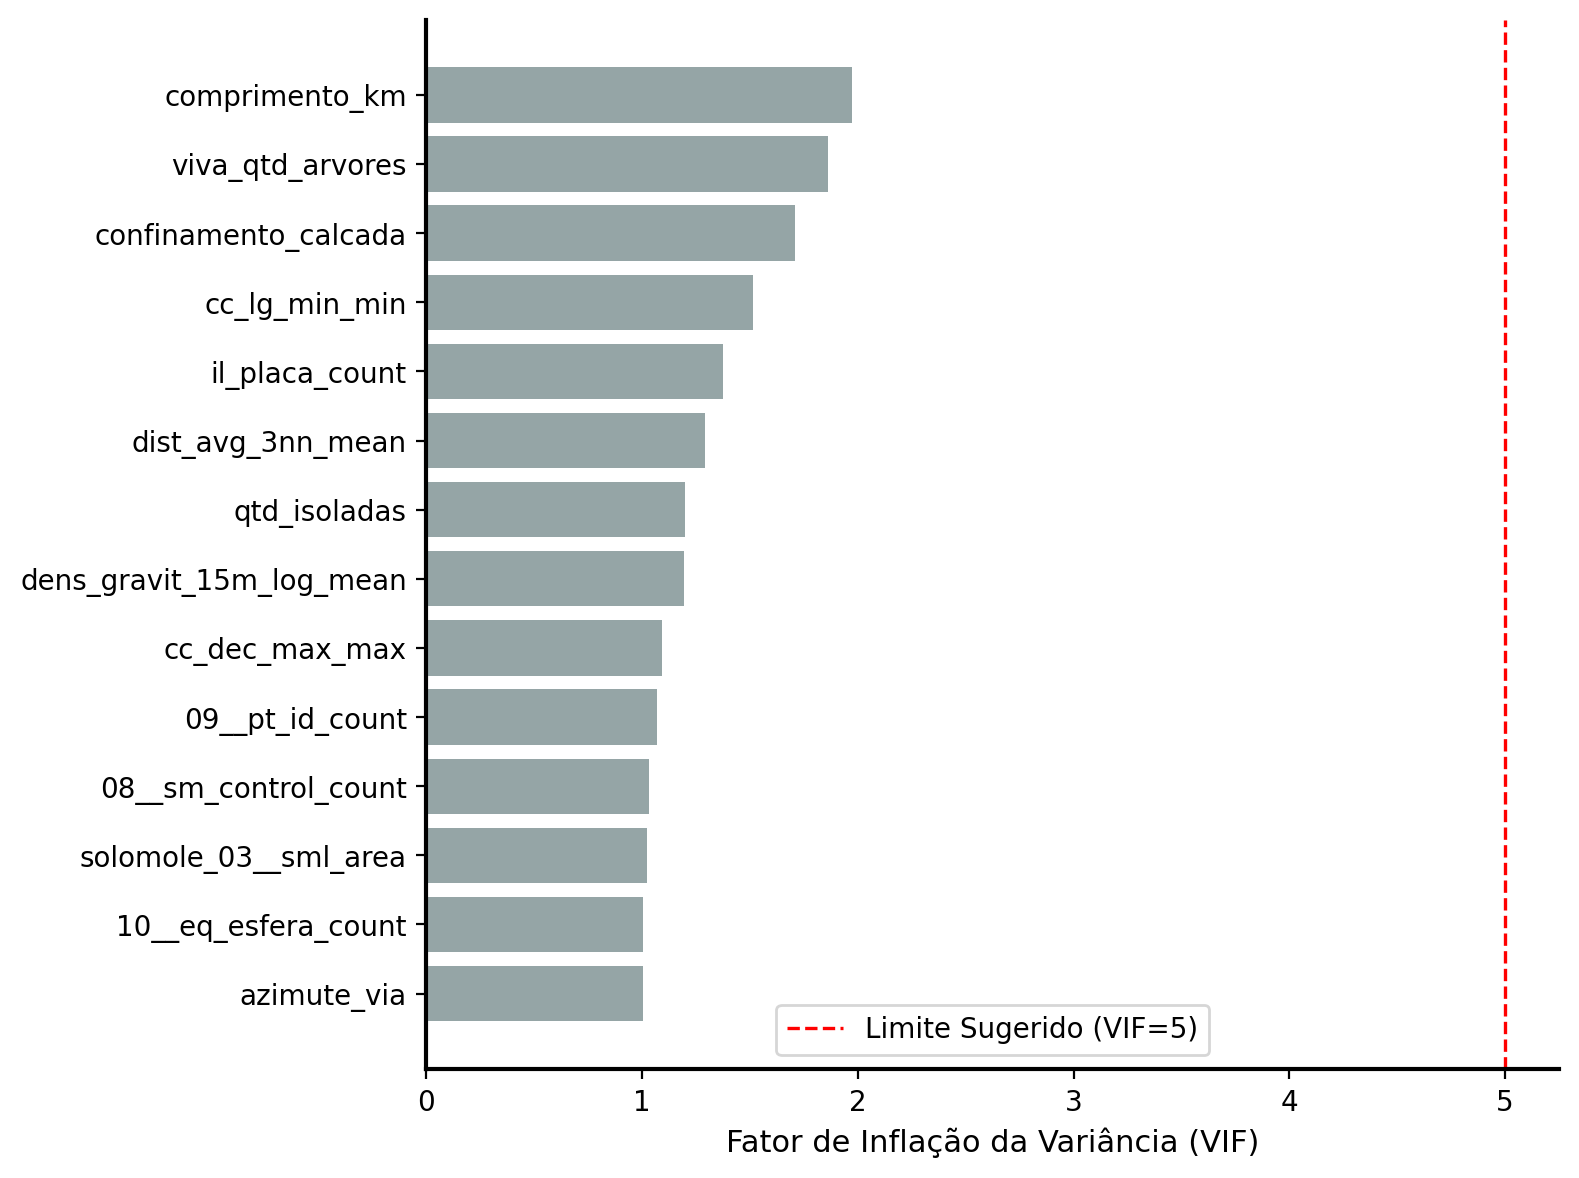


🔬 AVALIAÇÃO DE COLINEARIDADE: TRÍADE BIOMECÂNICA
Valores de VIF abaixo de 5 indicam que nossas variáveis físicas medem fenômenos distintos.


,Variável,VIF
11,dens_gravit_15m_log_mean,1.195540
10,dist_avg_3nn_mean,1.290519
14,confinamento_calcada,1.709799



✅ Tabela VIF completa exportada com sucesso em: results/tables/02_tabela_vif_20260324-1748_restritivo_km-arvores.csv


In [ ]:
# ==============================================================================
# CÉLULA 3: AUDITORIA ESTATÍSTICA E COLINEARIDADE (VIF)
# ==============================================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from IPython.display import display

print("🔬 Iniciando Auditoria Estatística: Análise de Multicolinearidade (VIF)...")
os.makedirs('results/figures', exist_ok=True)

# 1. Preparação dos Dados (Usamos apenas X_train para evitar Data Leakage)
# Preenchemos nulos com a mediana temporariamente pois o statsmodels não aceita NaN
X_vif_raw = X_train[features_numericas].copy().fillna(X_train[features_numericas].median())
X_vif_const = add_constant(X_vif_raw)

# 2. Cálculo do VIF
vif_data = pd.DataFrame({
    "Variável": X_vif_const.columns,
    "VIF": [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]
})

# Removemos a linha da 'const' para o gráfico não ficar poluído e ordenamos
vif_data = vif_data[vif_data['Variável'] != 'const'].sort_values('VIF', ascending=True)

# 3. Gráfico de VIF
fig_vif, ax_vif = plt.subplots(figsize=(8, 6))
ax_vif.barh(vif_data['Variável'], vif_data['VIF'], color='#95a5a6')
ax_vif.set_xlabel('Fator de Inflação da Variância (VIF)')
ax_vif.set_title('Análise de Multicolinearidade (Variáveis Físicas)')

# Linha de corte rigorosa (VIF > 5 indica colinearidade moderada)
ax_vif.axvline(x=5.0, color='red', linestyle='--', linewidth=1.2, label='Limite Sugerido (VIF=5)')
ax_vif.legend()

# Aplicar sua função de padronização (Arial, eixos, etc)
if 'aplicar_padrao_esalq' in globals():
    aplicar_padrao_esalq(ax_vif)

plt.tight_layout()

# Salvar com sufixo de data se a variável global existir
nome_arquivo_vif = f'results/figures/figura_vif_cidade{sufixo_data}.jpg' if 'sufixo_data' in globals() else 'results/figures/figura_vif_cidade.jpg'
plt.savefig(nome_arquivo_vif, dpi=300, bbox_inches='tight')
plt.show()

# 4. Avaliação Focada na Hipótese
print("\n🔬 AVALIAÇÃO DE COLINEARIDADE: TRÍADE BIOMECÂNICA")
print("Valores de VIF abaixo de 5 indicam que nossas variáveis físicas medem fenômenos distintos.")
triade_cols = ['dens_gravit_15m_log_mean', 'dist_avg_3nn_mean', 'confinamento_calcada']
vif_triade = vif_data[vif_data['Variável'].isin(triade_cols)]
display(vif_triade)

# ==============================================================================
# 5. EXPORTAÇÃO DA TABELA VIF (CSV)
# ==============================================================================
os.makedirs('results/tables', exist_ok=True)

nome_arquivo_csv = f'results/tables/02_tabela_vif{sufixo_data}.csv' if 'sufixo_data' in globals() else 'results/tables/02_tabela_vif.csv'

# Salva a tabela completa arredondando o VIF para 4 casas decimais para ficar limpo
vif_data.round(4).to_csv(nome_arquivo_csv, sep=';', decimal=',', index=False)
print(f"\n✅ Tabela VIF completa exportada com sucesso em: {nome_arquivo_csv}")

In [ ]:
# ==============================================================================
# CÉLULA 4: OTIMIZAÇÃO DO XGBOOST (K-FOLD ESPACIAL) COM CACHE
# ==============================================================================
import os
import json
from datetime import datetime
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from xgboost import XGBClassifier

print("⚙️ Construindo Pré-processador universal...")

# 1. Pipelines de Pré-processamento
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='DESCONHECIDO')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

pre_processador = ColumnTransformer(transformers=[
    ('num', num_pipeline, features_numericas),
    ('cat', cat_pipeline, features_categoricas)
])

# 2. Inicialização do Modelo XGBoost Base (Sem os hiperparâmetros ainda)
peso = (len(y_train) - y_train.sum()) / y_train.sum() if y_train.sum() > 0 else 1
pipeline_xgb_base = Pipeline([
    ('pre', pre_processador),
    ('modelo', XGBClassifier(random_state=42, scale_pos_weight=peso))
])

# 3. Lógica de Busca e Cache
pasta_modelos = 'results/models'
os.makedirs(pasta_modelos, exist_ok=True)
caminho_params = f'{pasta_modelos}/xgb_best_params.json'

# Puxa as Zonas Fiscais diretamente do df original, mantendo o alinhamento com o X_train
groups_train = df_modelagem.loc[X_train.index, 'fiscal_zf_sigla']

if os.path.exists(caminho_params):
    print(f"📥 Cache encontrado! Carregando melhores parâmetros de: {caminho_params}")
    with open(caminho_params, 'r') as f:
        best_params = json.load(f)
    print(f"✅ Parâmetros carregados: {best_params}")
else:
    print("⏳ Nenhum cache encontrado. Iniciando Validação Cruzada Espacial (isso pode demorar)...")
    param_dist = {
        'modelo__n_estimators': [100, 200, 300],
        'modelo__max_depth': [3, 4, 5, 7],
        'modelo__learning_rate': [0.01, 0.05, 0.1],
        'modelo__subsample': [0.7, 0.8, 0.9],
        'modelo__reg_alpha': [0, 0.1, 1, 10],   # Penalidade L1
        'modelo__reg_lambda': [1, 5, 10, 20]    # Penalidade L2
    }

    search_xgb = RandomizedSearchCV(
        pipeline_xgb_base,
        param_distributions=param_dist,
        n_iter=10,
        scoring='recall',
        cv=GroupKFold(n_splits=5),
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    # Executa a busca
    search_xgb.fit(X_train, y_train, groups=groups_train)
    best_params = search_xgb.best_params_

    print(f"✅ Melhores parâmetros encontrados: {best_params}")
    with open(caminho_params, 'w') as f:
        json.dump(best_params, f, indent=4)
    print(f"💾 Parâmetros salvos com sucesso!")

    # ==========================================================================
    # 4. EXPORTAÇÃO DO RELATÓRIO DE OTIMIZAÇÃO (TXT)
    # ==========================================================================
    os.makedirs('results/tables', exist_ok=True)
    sufixo = sufixo_data if 'sufixo_data' in globals() else datetime.now().strftime("_%Y%m%d-%H%M")
    caminho_txt_opt = f'results/tables/03_relatorio_otimizacao_xgb{sufixo}.txt'

    with open(caminho_txt_opt, 'w', encoding='utf-8') as f:
        f.write("========================================================\n")
        f.write("      RELATÓRIO DE OTIMIZAÇÃO DE HIPERPARÂMETROS (XGB)  \n")
        f.write("========================================================\n\n")

        f.write("1. ESPAÇO DE BUSCA (param_dist):\n")
        for k, v in param_dist.items():
            f.write(f"   {k}: {v}\n")

        f.write("\n2. CONFIGURAÇÃO DO SEARCH (RandomizedSearchCV):\n")
        f.write(f"   Iterações (n_iter): {search_xgb.n_iter}\n")
        f.write(f"   Métrica de Avaliação (scoring): {search_xgb.scoring}\n")
        f.write(f"   Validação Cruzada (cv): GroupKFold(n_splits=5)\n")
        f.write(f"   Estratégia de Agrupamento: Zonas Fiscais ('fiscal_zf_sigla')\n")

        f.write("\n3. MELHORES PARÂMETROS ENCONTRADOS (best_params):\n")
        for k, v in best_params.items():
            f.write(f"   {k}: {v}\n")

    print(f"📝 Relatório de otimização exportado em: {caminho_txt_opt}")

⚙️ Construindo Pré-processador universal...
📥 Cache encontrado! Carregando melhores parâmetros de: results/models/xgb_best_params.json
✅ Parâmetros carregados: {'modelo__subsample': 0.8, 'modelo__reg_lambda': 1, 'modelo__reg_alpha': 1, 'modelo__n_estimators': 300, 'modelo__max_depth': 3, 'modelo__learning_rate': 0.01}


# treino

In [ ]:
# ==============================================================================
# CÉLULA 5: TREINAMENTO OFICIAL E GERAÇÃO DE PROBABILIDADES
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

print("🚀 Iniciando o Treinamento Oficial...")

# 1. Configurando o modelo XGBoost com os super parâmetros otimizados
pipeline_xgb = pipeline_xgb_base.set_params(**best_params)

# 2. Configurando os outros modelos (Baselines e Lasso)
dummy_freq = DummyClassifier(strategy='most_frequent')
dummy_strat = DummyClassifier(strategy='stratified', random_state=42)

pipeline_lasso = Pipeline([
    ('pre', pre_processador),
    ('modelo', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=0.1, random_state=42))
])

# 3. Treinamento
print("⏳ Treinando XGBoost, Lasso e Baselines...")
dummy_freq.fit(X_train, y_train)
dummy_strat.fit(X_train, y_train)
pipeline_lasso.fit(X_train, y_train)
pipeline_xgb.fit(X_train, y_train)

# 4. Geração de Probabilidades para Teste
y_prob_freq = dummy_freq.predict_proba(X_test)[:, 1]
y_prob_strat = dummy_strat.predict_proba(X_test)[:, 1]
y_prob_lasso = pipeline_lasso.predict_proba(X_test)[:, 1]
y_prob_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]

print("✅ Treinamento concluído e probabilidades geradas!")

🚀 Iniciando o Treinamento Oficial...
⏳ Treinando XGBoost, Lasso e Baselines...
✅ Treinamento concluído e probabilidades geradas!


# otimização do custo

In [ ]:
# ==============================================================================
# CÉLULA 6: SIMULAÇÃO DE CUSTO OPERACIONAL (JUSTIFICATIVA DO THRESHOLD)
# ==============================================================================
import os
from sklearn.metrics import confusion_matrix, recall_score, precision_score

# Garante que a estrutura de pastas para os resultados existe
os.makedirs('results/tables', exist_ok=True)

limiares_teste = [0.50, 0.45, 0.40, 0.35, 0.30]
resultados_simulacao = []

for limiar in limiares_teste:
    y_pred_sim = (y_prob_xgb >= limiar).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_sim).ravel()

    recall = recall_score(y_test, y_pred_sim)
    precisao = precision_score(y_test, y_pred_sim, zero_division=0)

    resultados_simulacao.append({
        'Threshold': limiar,
        'Recall (Segurança) %': f"{recall*100:.1f}%",
        'Precisão (Assertividade) %': f"{precisao*100:.1f}%",
        'Quedas Detectadas (VP)': tp,
        'Riscos Omitidos (FN)': fn,
        'Alarmes Falsos (FP)': fp,
        'Vistorias Totais (Carga)': tp + fp
    })

df_simulacao = pd.DataFrame(resultados_simulacao).set_index('Threshold')

print("🚦 SIMULAÇÃO: TRADE-OFF ENTRE SEGURANÇA OPERACIONAL E ALOCAÇÃO DE EQUIPES")
display(df_simulacao)

# Exporta com separador de ponto e vírgula para abrir direto no Excel (Padrão PT-BR)
df_simulacao.to_csv(f'results/tables/simulacao_custo_operacional{sufixo_data}.csv', sep=';', decimal=',')
print("\n✅ Tabela de simulação exportada para 'results/tables/'.")

🚦 SIMULAÇÃO: TRADE-OFF ENTRE SEGURANÇA OPERACIONAL E ALOCAÇÃO DE EQUIPES


,Recall (Segurança) %,Precisão (Assertividade) %,Quedas Detectadas (VP),Riscos Omitidos (FN),Alarmes Falsos (FP),Vistorias Totais (Carga)
Threshold,,,,,,
0.50,64.2%,12.5%,923,515,6474,7397
0.45,74.1%,11.1%,1066,372,8559,9625
0.40,82.6%,9.6%,1188,250,11144,12332
0.35,89.4%,8.7%,1285,153,13436,14721
0.30,95.3%,7.9%,1370,68,16044,17414



✅ Tabela de simulação exportada para 'results/tables/'.


🔍 Gerando probabilidades Out-Of-Fold no Treino (Isso garante rigor científico)...
⚙️ Otimizando o limiar com base na matriz de custos operacionais...
✅ OTIMIZAÇÃO CONCLUÍDA NO TREINO:
   -> Threshold Operacional Ótimo: 0.45
   -> Economia Simulada na base de treino: R$ 63,731,300.00

🚀 Aplicando o limiar congelado na base de Teste (Cenário Futuro)...
💰 ECONOMIA COMPROVADA NO TESTE (VALOR PARA A TESE): R$ 16,257,100.00


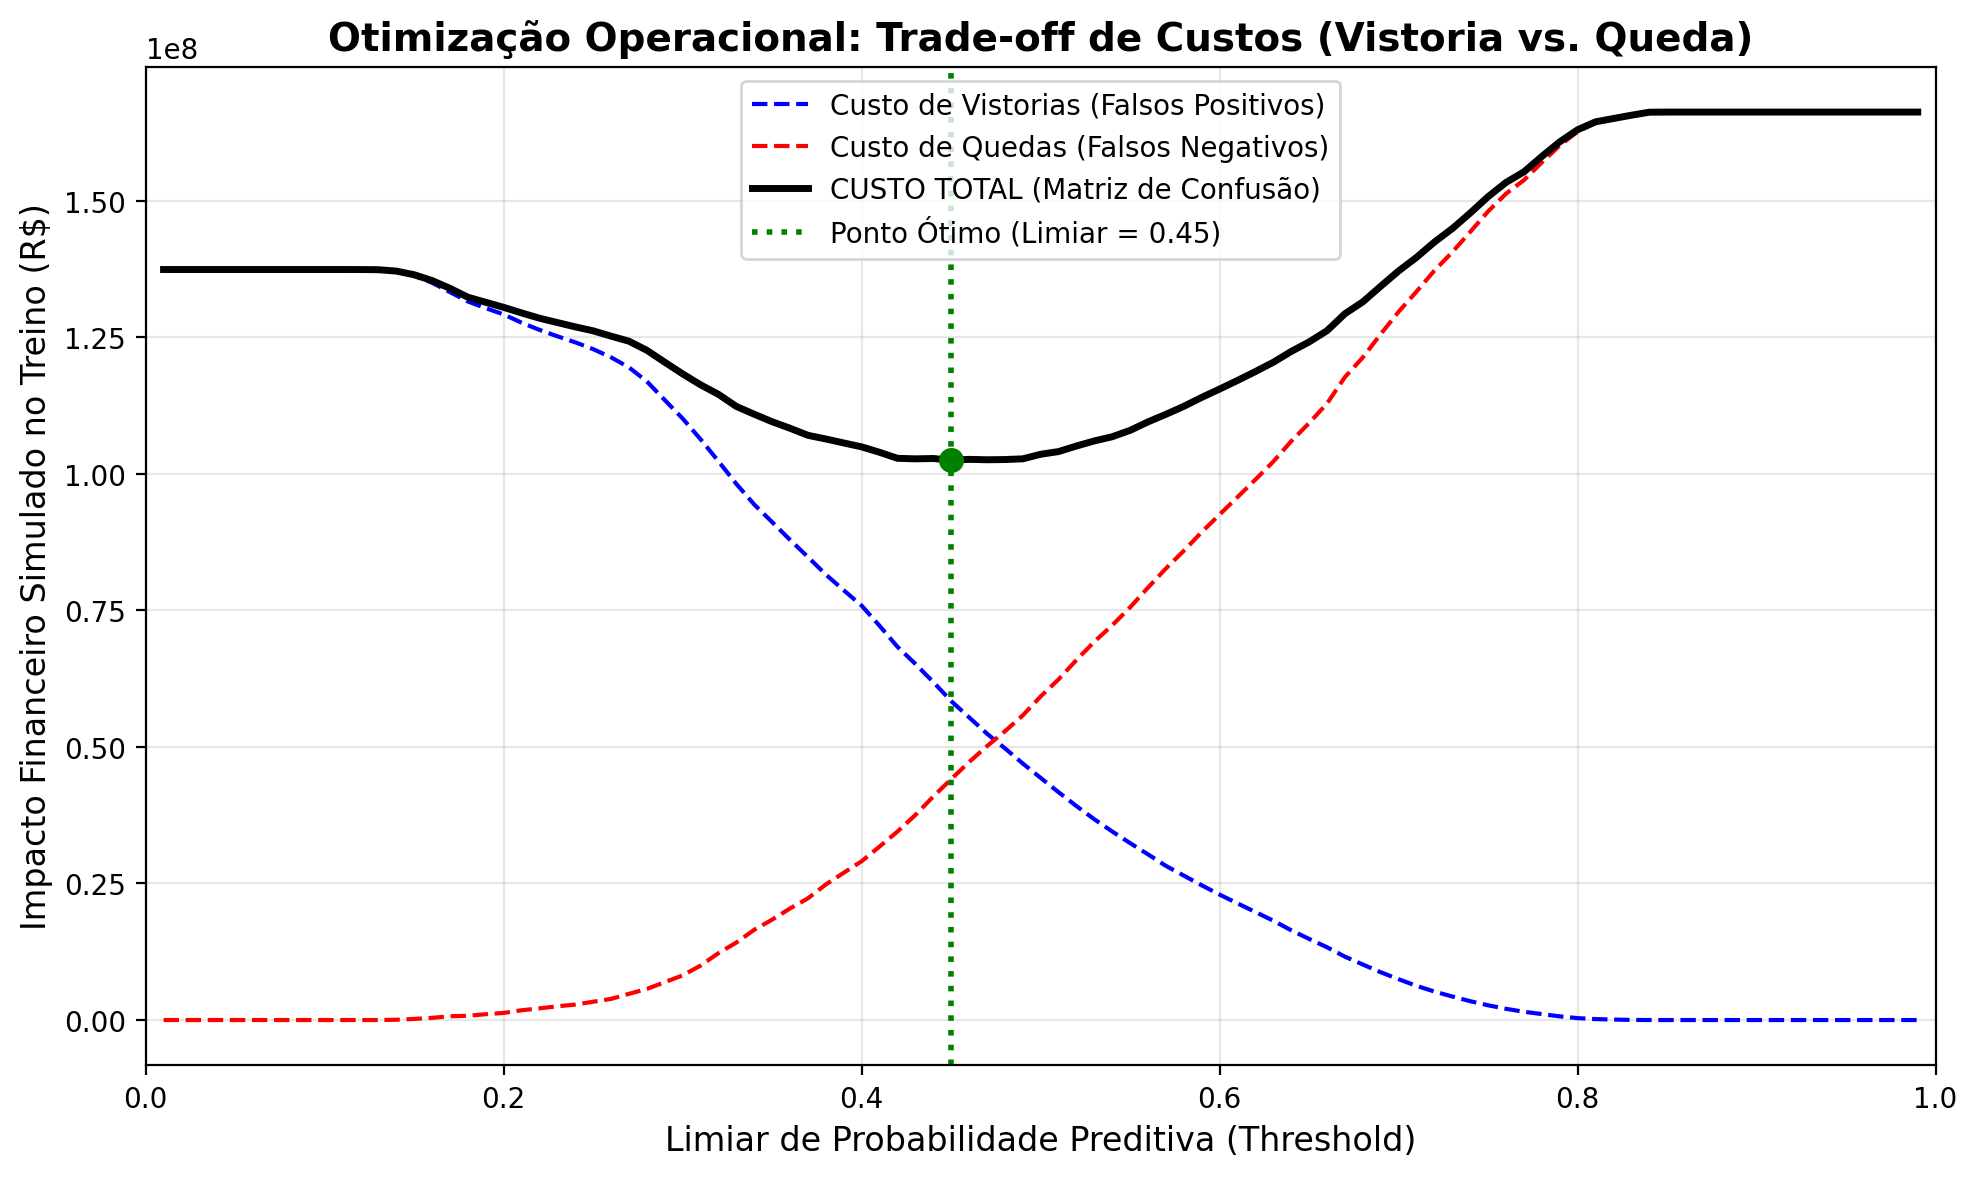

✅ Gráfico de simulação financeira exportado com sucesso!


In [ ]:
# ==============================================================================
# CÉLULA 7: OTIMIZAÇÃO DO THRESHOLD DE RISCO (FINANCEIRO) - BLINDADA CONTRA LEAKAGE
# ==============================================================================
from sklearn.model_selection import cross_val_predict
import numpy as np
import matplotlib.pyplot as plt

print("🔍 Gerando probabilidades Out-Of-Fold no Treino (Isso garante rigor científico)...")

# 1. GERAÇÃO DO OOF (O que Entra: X_train, y_train | O que Sai: y_prob_train_oof)
y_prob_train_oof = cross_val_predict(pipeline_xgb, X_train, y_train, cv=5, method='predict_proba')[:, 1]

"""
Módulo: simulacao_impacto_economico.py
Contexto Histórico e Premissas de Custo (Dezembro/2025)

Este módulo armazena as constantes de custo baseadas nos dados reais de 2025
para a calibração do threshold do modelo XGBoost.

DADOS DE REFERÊNCIA (DEZ/2025):
-------------------------------
1. Impacto Varejo: R$ 77,5 milhões (para 438 quedas).
2. Impacto Médio por Árvore [CUSTO_FALSO_NEGATIVO]: R$ 177.000,00 (Perda direta no comércio).
3. Impacto Sistêmico Máximo: R$ 3.500.000,00 (Árvores que atingem rede elétrica).
4. Custo de Manejo (PMSP) [CUSTO_FALSO_POSITIVO]: R$ 1.500,00 a R$ 8.000,00 (Remoção/Limpeza).
5. Manejo acima de 5 (cinco) até 35 (trinta e cinco) exemplares arbóreos: R$ 1.700,00 (TCA - Termo de Compromisso Ambiental).
https://prefeitura.sp.gov.br/web/meio_ambiente/w/menu/246510

CONCEITO DE TRADE-OFF:
A disparidade entre o Custo de Manejo (R$ 8k) e o Prejuízo Sistêmico (R$ 3.5M)
exige uma calibração de Threshold conservadora (Priorização de Recall).
"""

# 2. DEFINIÇÃO DE CUSTOS (Conforme a premissa da prefeitura)
CUSTO_FALSO_POSITIVO = 1700  # Custo de vistoria/poda desnecessária
CUSTO_FALSO_NEGATIVO = 17*CUSTO_FALSO_POSITIVO # Custo do dano de uma queda não prevista

threshold_otimo = 0.5
menor_custo_total = float('inf')
economia_no_treino = 0

# Listas para guardar o histórico do gráfico
lista_thresholds = []
lista_custos_fp = []
lista_custos_fn = []
lista_custos_totais = []

print("⚙️ Otimizando o limiar com base na matriz de custos operacionais...")

# 3. O LOOP FINANCEIRO NO TREINO
for threshold in np.arange(0.01, 1.0, 0.01):
    # Simulando as predições no treino usando o threshold atual
    pred_simulada = (y_prob_train_oof >= threshold).astype(int)

    # Calculando os erros no TREINO
    fp = np.sum((pred_simulada == 1) & (y_train == 0))
    fn = np.sum((pred_simulada == 0) & (y_train == 1))

    # Custo da matriz
    custo_fp_atual = fp * CUSTO_FALSO_POSITIVO
    custo_fn_atual = fn * CUSTO_FALSO_NEGATIVO
    custo_atual = custo_fp_atual + custo_fn_atual

    # Guardando na memória para o gráfico
    lista_thresholds.append(threshold)
    lista_custos_fp.append(custo_fp_atual)
    lista_custos_fn.append(custo_fn_atual)
    lista_custos_totais.append(custo_atual)

# Identificar o ponto exato de menor custo a partir das listas geradas
indice_menor_custo = np.argmin(lista_custos_totais)
threshold_otimo = lista_thresholds[indice_menor_custo]
menor_custo_total = lista_custos_totais[indice_menor_custo]

# Economia em relação a não fazer nada (deixar tudo cair = fn máximo)
custo_base_sem_modelo = np.sum(y_train == 1) * CUSTO_FALSO_NEGATIVO
economia_no_treino = custo_base_sem_modelo - menor_custo_total

print(f"✅ OTIMIZAÇÃO CONCLUÍDA NO TREINO:")
print(f"   -> Threshold Operacional Ótimo: {threshold_otimo:.2f}")
print(f"   -> Economia Simulada na base de treino: R$ {economia_no_treino:,.2f}")

# ==============================================================================
# 4. APLICAÇÃO NO MUNDO REAL (CONJUNTO DE TESTE)
# ==============================================================================
print("\n🚀 Aplicando o limiar congelado na base de Teste (Cenário Futuro)...")

# O que Entra: y_prob_xgb (Teste) | O que Sai: y_pred_final_teste
y_pred_final_teste = (y_prob_xgb >= threshold_otimo).astype(int)

# Calculando a economia REAL final para a tese
fp_teste = np.sum((y_pred_final_teste == 1) & (y_test == 0))
fn_teste = np.sum((y_pred_final_teste == 0) & (y_test == 1))

custo_modelo_teste = (fp_teste * CUSTO_FALSO_POSITIVO) + (fn_teste * CUSTO_FALSO_NEGATIVO)
custo_base_teste = np.sum(y_test == 1) * CUSTO_FALSO_NEGATIVO
economia_real_teste = custo_base_teste - custo_modelo_teste

print(f"💰 ECONOMIA COMPROVADA NO TESTE (VALOR PARA A TESE): R$ {economia_real_teste:,.2f}")

# Atualiza as predições do XGBoost na memória para as próximas células
y_pred_xgb = y_pred_final_teste

# ==========================================
# 5. PLOTAGEM DO GRÁFICO DE TRADE-OFF
# ==========================================
fig_custo, ax_custo = plt.subplots(figsize=(10, 6))

ax_custo.plot(lista_thresholds, lista_custos_fp, label='Custo de Vistorias (Falsos Positivos)', color='blue', linestyle='--')
ax_custo.plot(lista_thresholds, lista_custos_fn, label='Custo de Quedas (Falsos Negativos)', color='red', linestyle='--')
ax_custo.plot(lista_thresholds, lista_custos_totais, label='CUSTO TOTAL (Matriz de Confusão)', color='black', linewidth=2.5)

# Marcação do Threshold Ótimo
ax_custo.axvline(x=threshold_otimo, color='green', linestyle=':', linewidth=2,
                 label=f'Ponto Ótimo (Limiar = {threshold_otimo:.2f})')
ax_custo.plot(threshold_otimo, menor_custo_total, marker='o', markersize=8, color='green')

# Estética
ax_custo.set_title('Otimização Operacional: Trade-off de Custos (Vistoria vs. Queda)', fontsize=14, weight='bold')
ax_custo.set_xlabel('Limiar de Probabilidade Preditiva (Threshold)', fontsize=12)
ax_custo.set_ylabel('Impacto Financeiro Simulado no Treino (R$)', fontsize=12)
ax_custo.set_xlim(0, 1)
ax_custo.grid(alpha=0.3)
ax_custo.legend(loc='upper center', fontsize=10)

plt.tight_layout()

# Exportando o gráfico
import os
os.makedirs('results/figures', exist_ok=True)
if 'sufixo_data' in globals():
    caminho_fig_custo = f'results/figures/simulacao_custo_threshold{sufixo_data}.jpg'
else:
    caminho_fig_custo = 'results/figures/simulacao_custo_threshold.jpg'

plt.savefig(caminho_fig_custo, dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico de simulação financeira exportado com sucesso!")

# avaliação do modelo



In [ ]:
# ==============================================================================
# CÉLULA 8: TABELA FINAL DE MÉTRICAS (MODELOS OTIMIZADOS - CIDADE TODA)
# ==============================================================================
# Decisão Operacional: Limiar adotado para priorizar Recall (Segurança).
limiar_final = threshold_otimo

tabela_final = {
    'Baseline (Frequência)': calcular_metricas_limiar(y_true=y_test, y_prob=y_prob_freq, limiar=0.50),
    'Baseline (Estratificado)': calcular_metricas_limiar(y_true=y_test, y_prob=y_prob_strat, limiar=0.50),
    f'Regressão Lasso (Thr {limiar_final})': calcular_metricas_limiar(y_true=y_test, y_prob=y_prob_lasso, limiar=limiar_final),
    f'XGBoost (Thr {limiar_final})': calcular_metricas_limiar(y_true=y_test, y_prob=y_prob_xgb, limiar=limiar_final)
}

colunas_metricas = ['Recall (Segurança)', 'AUC', 'Gini', 'KS', 'Especificidade', 'Precisão', 'Acurácia']
df_metricas_finais = pd.DataFrame.from_dict(tabela_final, orient='index', columns=colunas_metricas)

# Ajuste de consistência: Mudança de ZF-1 para Cidade Inteira
print(f"📋 RESULTADOS FINAIS (ESCAlA URBANA - SÃO PAULO, LIMIAR {limiar_final}):")
display(df_metricas_finais)

# Exportação com nome coerente ao novo escopo
caminho_tabela = f'results/tables/tabela_metricas_finais_cidade_toda{sufixo_data}.csv'
df_metricas_finais.to_csv(caminho_tabela, sep=';', decimal=',')
print(f"✅ Tabela final salva em: {caminho_tabela}")

📋 RESULTADOS FINAIS (ESCAlA URBANA - SÃO PAULO, LIMIAR 0.45):


,Recall (Segurança),AUC,Gini,KS,Especificidade,Precisão,Acurácia
Baseline (Frequência),0.00%,50.00%,0.00%,0.00%,100.00%,0.00%,93.36%
Baseline (Estratificado),6.40%,49.83%,-0.33%,0.33%,93.27%,6.34%,87.50%
Regressão Lasso (Thr 0.45),67.59%,70.58%,41.17%,31.63%,62.64%,11.41%,62.97%
XGBoost (Thr 0.45),74.13%,71.91%,43.82%,32.94%,57.65%,11.08%,58.74%


✅ Tabela final salva em: results/tables/tabela_metricas_finais_cidade_toda_20260324-1748_restritivo_km-arvores.csv


# features importance

📊 Extraindo a importância de todas as variáveis dos modelos...


/tmp/ipykernel_7527/373494211.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='XGBoost (Força %)', y='Feature', data=df_xgb_plot, ax=axes[0], palette='viridis')
/tmp/ipykernel_7527/373494211.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Lasso (Coeficiente)', y='Feature', data=df_lasso_plot, ax=axes[1], palette=cores_lasso)


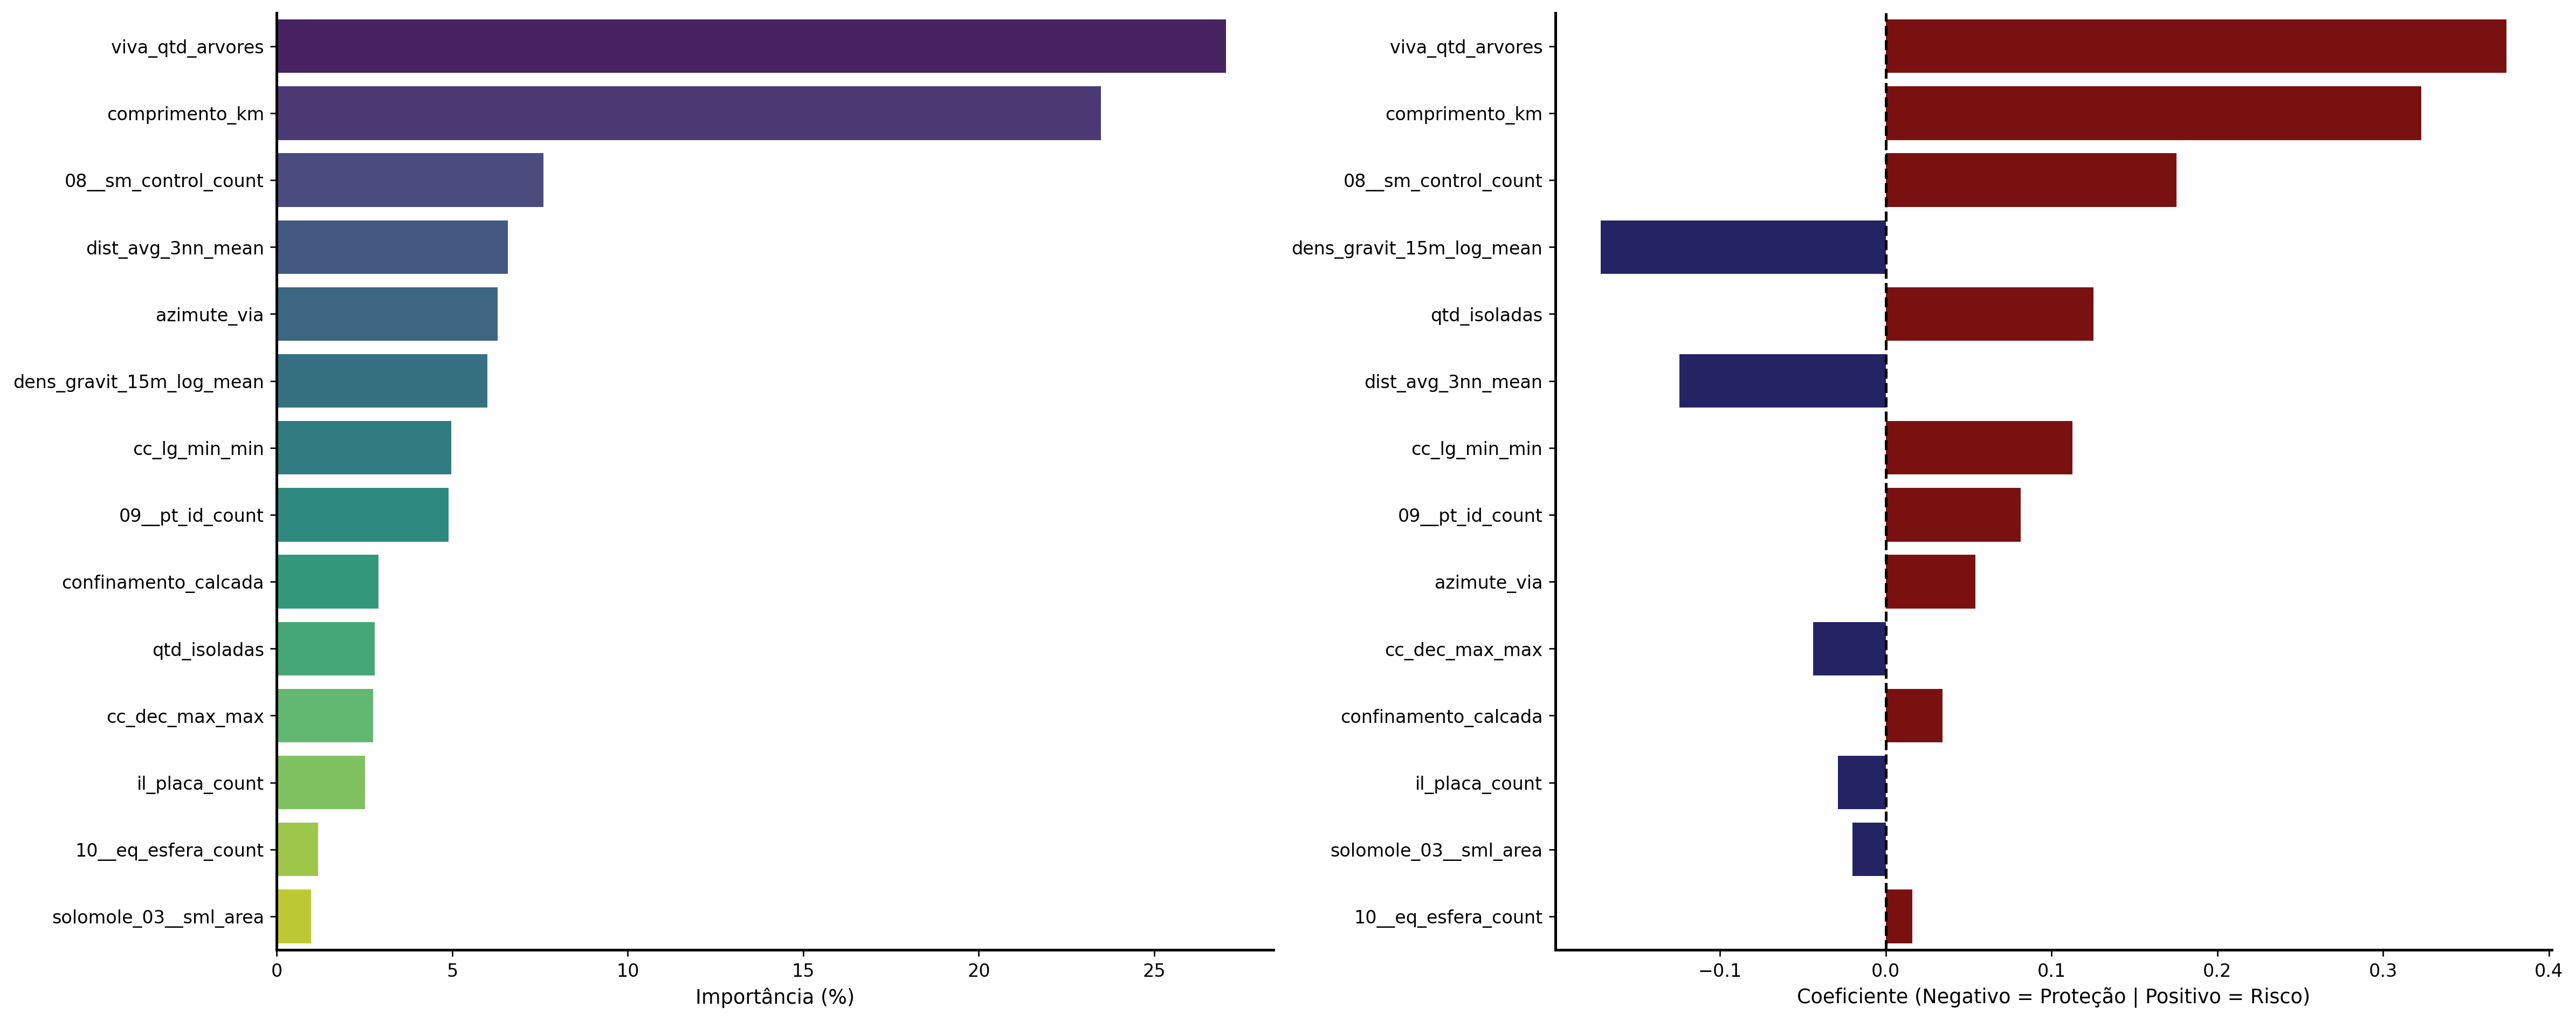

✅ Gráficos independentes gerados com sucesso!

🔍 RESUMO DA REGRESSÃO LASSO (Penalidade L1):
 - Sobreviveram: 14 variáveis.
 - Foram ZERADAS (descartadas por redundância ou irrelevância): 0 variáveis.

📈 FATORES DE RISCO (Coeficientes Positivos - Aumentam a chance de queda):
  + viva_qtd_arvores               | Peso: 0.3745
  + comprimento_km                 | Peso: 0.3231
  + 08__sm_control_count           | Peso: 0.1753
  + qtd_isoladas                   | Peso: 0.1253
  + cc_lg_min_min                  | Peso: 0.1127
  + 09__pt_id_count                | Peso: 0.0814
  + azimute_via                    | Peso: 0.0540
  + confinamento_calcada           | Peso: 0.0343
  + 10__eq_esfera_count            | Peso: 0.0160

🛡️ FATORES DE PROTEÇÃO (Coeficientes Negativos - Reduzem a chance de queda):
  - dens_gravit_15m_log_mean       | Peso: -0.1721
  - dist_avg_3nn_mean              | Peso: -0.1246
  - cc_dec_max_max                 | Peso: -0.0438
  - il_placa_count                 | Peso: -

In [ ]:
# ==============================================================================
# CÉLULA 9: INTERPRETABILIDADE EXAUSTIVA (TODAS AS VARIÁVEIS ATIVAS E DESCARTADAS)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("📊 Extraindo a importância de todas as variáveis dos modelos...")

# 1. Extração dos Dados Brutos
coeficientes_lasso = pipeline_lasso.named_steps['modelo'].coef_[0]
feature_names = pipeline_lasso.named_steps['pre'].get_feature_names_out()
feature_names_clean = [nome.replace('num__', '').replace('cat__', '') for nome in feature_names]

importancias_xgb = pipeline_xgb.named_steps['modelo'].feature_importances_ * 100

# 2. Consolidando no DataFrame Principal
df_importancia = pd.DataFrame({
    'Feature': feature_names_clean,
    'XGBoost (Força %)': importancias_xgb,
    'Lasso (Coeficiente)': coeficientes_lasso
})

# 3. Filtragem Independente para cada Modelo
# XGBoost: Apenas variáveis que contribuíram com algum ganho de informação (> 0)
df_xgb_plot = df_importancia[df_importancia['XGBoost (Força %)'] > 0].sort_values(by='XGBoost (Força %)', ascending=False)

# Lasso: Apenas variáveis que sobreviveram à penalidade L1 (!= 0)
df_lasso_plot = df_importancia[df_importancia['Lasso (Coeficiente)'] != 0].copy()
df_lasso_plot['Abs_Lasso'] = df_lasso_plot['Lasso (Coeficiente)'].abs()
df_lasso_plot = df_lasso_plot.sort_values(by='Abs_Lasso', ascending=False)

# Lasso: Variáveis Zeradas (Descartadas)
df_lasso_zeradas = df_importancia[df_importancia['Lasso (Coeficiente)'] == 0][['Feature']].copy()

# 4. Salvando as tabelas completas para o relatório
caminho_tabela_xgb = f'results/tables/tabela_xgboost_ativas{sufixo_data if "sufixo_data" in globals() else ""}.csv'
caminho_tabela_lasso = f'results/tables/tabela_lasso_ativas{sufixo_data if "sufixo_data" in globals() else ""}.csv'
df_xgb_plot.to_csv(caminho_tabela_xgb, index=False)
df_lasso_plot.to_csv(caminho_tabela_lasso, index=False)

# ==========================================
# 5. PLOTANDO OS GRÁFICOS DINÂMICOS
# ==========================================
# Calcula a altura ideal do gráfico baseado no modelo que tem mais variáveis ativas
max_vars = max(len(df_xgb_plot), len(df_lasso_plot))
altura_ideal = max(8, max_vars * 0.35) # Garante pelo menos 8 polegadas, ou cresce dinamicamente

fig, axes = plt.subplots(1, 2, figsize=(20, altura_ideal), dpi=120)

# Gráfico 1: XGBoost (Força Absoluta)
sns.barplot(x='XGBoost (Força %)', y='Feature', data=df_xgb_plot, ax=axes[0], palette='viridis')
axes[0].set_title(f'Variáveis Ativas: XGBoost ({len(df_xgb_plot)} features)', fontsize=14, weight='bold')
axes[0].set_xlabel('Importância (%)')
axes[0].set_ylabel('')

# Gráfico 2: Lasso (Direcionalidade)
cores_lasso = ['#8B0000' if val > 0 else '#191970' for val in df_lasso_plot['Lasso (Coeficiente)']]
sns.barplot(x='Lasso (Coeficiente)', y='Feature', data=df_lasso_plot, ax=axes[1], palette=cores_lasso)
axes[1].set_title(f'Variáveis Ativas: Regressão Lasso ({len(df_lasso_plot)} features)', fontsize=14, weight='bold')
axes[1].set_xlabel('Coeficiente (Negativo = Proteção | Positivo = Risco)')
axes[1].set_ylabel('')
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--') # Linha central destacada

# Formatação padrão ESALQ se disponível
if 'aplicar_padrao_esalq' in globals():
    aplicar_padrao_esalq(axes[0])
    aplicar_padrao_esalq(axes[1])

plt.tight_layout()
plt.savefig(f'results/figures/importancia_exaustiva_modelos{sufixo_data if "sufixo_data" in globals() else ""}.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 6. RELATÓRIO DE DESCARTE (LASSO)
# ==========================================
print("✅ Gráficos independentes gerados com sucesso!")
print(f"\n🔍 RESUMO DA REGRESSÃO LASSO (Penalidade L1):")
print(f" - Sobreviveram: {len(df_lasso_plot)} variáveis.")
print(f" - Foram ZERADAS (descartadas por redundância ou irrelevância): {len(df_lasso_zeradas)} variáveis.")

if len(df_lasso_zeradas) > 0:
    print("\n🗑️ Variáveis descartadas pelo Lasso:")
    lista_zeradas = df_lasso_zeradas['Feature'].tolist()
    # Imprime em formato de bloco para não poluir muito a tela
    for i in range(0, len(lista_zeradas), 3):
        print(" | ".join(lista_zeradas[i:i+3]))

# ==============================================================================
# 7. RELATÓRIO DETALHADO: FATORES DE RISCO E PROTEÇÃO (LASSO)
# ==============================================================================
print("\n📈 FATORES DE RISCO (Coeficientes Positivos - Aumentam a chance de queda):")
# Filtra maiores que 0 e ordena do maior para o menor risco
risco_lasso = df_lasso_plot[df_lasso_plot['Lasso (Coeficiente)'] > 0].sort_values(by='Lasso (Coeficiente)', ascending=False)

if not risco_lasso.empty:
    for _, row in risco_lasso.iterrows():
        print(f"  + {row['Feature']:<30} | Peso: {row['Lasso (Coeficiente)']:.4f}")
else:
    print("  Nenhum fator de risco retido pelo modelo.")

print("\n🛡️ FATORES DE PROTEÇÃO (Coeficientes Negativos - Reduzem a chance de queda):")
# Filtra menores que 0 e ordena do mais negativo para o menos negativo (maior proteção primeiro)
protecao_lasso = df_lasso_plot[df_lasso_plot['Lasso (Coeficiente)'] < 0].sort_values(by='Lasso (Coeficiente)', ascending=True)

if not protecao_lasso.empty:
    for _, row in protecao_lasso.iterrows():
        print(f"  - {row['Feature']:<30} | Peso: {row['Lasso (Coeficiente)']:.4f}")
else:
    print("  Nenhum fator de proteção retido pelo modelo.")

# mapas

In [ ]:
# ==============================================================================
# CÉLULA 10: PREDIÇÃO PARA A CIDADE INTEIRA E CRIAÇÃO DO DF_MAPA
# ==============================================================================
print("🌍 Aplicando o modelo otimizado para toda a malha viária de São Paulo...")

# 1. Copiamos o dataframe mestre original (que contém a coluna 'geometry')
df_mapa = df_full.copy()

# 2. Separamos os dados de entrada para o modelo
X_cidade = df_mapa[features_numericas + features_categoricas]

# 3. Geramos as probabilidades usando o XGBoost otimizado
# Preenchemos NAs numéricos temporariamente com a mediana (caso tenha ficado algum para trás)
X_cidade_clean = X_cidade.copy()
X_cidade_clean[features_numericas] = X_cidade_clean[features_numericas].fillna(X_train[features_numericas].median())

df_mapa['Prob_Queda'] = pipeline_xgb.predict_proba(X_cidade_clean)[:, 1]

# 4. Classificação do Risco Baseada no Threshold da Simulação Financeira (4 NÍVEIS)
# Se o threshold_otimo não existir na memória, usamos 0.35 como segurança
limiar_acao = threshold_otimo if 'threshold_otimo' in globals() else 0.35

def classificar_risco(prob):
    # A régua é calibrada pelo threshold ótimo que descobrimos financeiramente
    if prob >= limiar_acao * 1.5:
        return '1. Crítico'   # Ação Imediata (Emergência)
    elif prob >= limiar_acao:
        return '2. Alto'      # Ação Necessária (Custo/Benefício atingido)
    elif prob >= limiar_acao * 0.5:
        return '3. Moderado'  # Atenção / Monitoramento futuro
    else:
        return '4. Baixo'     # Risco irrelevante operacionalmente

df_mapa['Nivel_Risco'] = df_mapa['Prob_Queda'].apply(classificar_risco)

print(f"✅ df_mapa criado! O limiar operacional de risco 'Alto' foi definido em: {limiar_acao:.2f}")
print("Contagem de vias por Nível de Risco:")
print(df_mapa['Nivel_Risco'].value_counts().sort_index())

🌍 Aplicando o modelo otimizado para toda a malha viária de São Paulo...
✅ df_mapa criado! O limiar operacional de risco 'Alto' foi definido em: 0.45
Contagem de vias por Nível de Risco:
Nivel_Risco
1. Crítico      9985
2. Alto        38314
3. Moderado    51286
4. Baixo        8641
Name: count, dtype: int64


In [ ]:
# ==============================================================================
# CÉLULA 10.1: RENDERIZAÇÃO DO MAPA ESTÁTICO DE ALTA RESOLUÇÃO
# ==============================================================================
print("🎨 Renderizando mapa estático de alta resolução (300 DPI)...")

import os
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. RECUPERAR A NATUREZA ESPACIAL DA TABELA
if isinstance(df_mapa['geometry'].iloc[0], bytes):
    df_mapa['geometry'] = gpd.GeoSeries.from_wkb(df_mapa['geometry'])

# Convertendo a tabela normal (df) para um mapa (gdf)
gdf_mapa = gpd.GeoDataFrame(df_mapa, geometry='geometry', crs="EPSG:31983")

# 2. PLOTAGEM DO MAPA
fig, ax = plt.subplots(figsize=(12, 16))

paleta_risco = {
    '1. Crítico': '#D32F2F',    # Vermelho Carmim
    '2. Alto': '#FBC02D',       # Amarelo Ouro
    '3. Moderado': '#7CB342',   # Verde Maçã (Agradável)
    '4. Baixo': '#E0E0E0'       # Cinza Neutro
}

# Ordem de plotagem: Baixo para Cima (Garante que o Crítico seja desenhado por cima de tudo)
ordem_plotagem = ['4. Baixo', '3. Moderado', '2. Alto', '1. Crítico']

for nivel in ordem_plotagem:
    subset = gdf_mapa[gdf_mapa['Nivel_Risco'] == nivel]
    if not subset.empty:
        # Ruas de risco baixo ficam com linha mais fina para não poluir
        espessura = 0.4 if nivel == '4. Baixo' else 0.8
        subset.plot(ax=ax, color=paleta_risco[nivel], linewidth=espessura)

# Estética Acadêmica
ax.set_axis_off()
ax.set_title('Mapa Preditivo de Risco de Queda de Árvores\nMalha Viária do Município de São Paulo',
             fontsize=16, pad=20, weight='bold')

# Legenda Manual
legend_patches = [mpatches.Patch(color=paleta_risco[n], label=n) for n in ordem_plotagem[::-1]]
ax.legend(handles=legend_patches, title="Prioridade Operacional",
          loc='lower right', frameon=False, fontsize=11, title_fontsize=12)

# Exportação
os.makedirs('results/figures', exist_ok=True)
if 'sufixo_data' in globals():
    caminho_mapa = f'results/figures/03_mapa_risco_final_sp{sufixo_data}.png'
else:
    caminho_mapa = 'results/figures/03_mapa_risco_final_sp.png'

plt.savefig(caminho_mapa, dpi=300, bbox_inches='tight', facecolor='white')

print(f"✅ Mapa final gerado com sucesso em: {caminho_mapa}")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ==============================================================================
# CÉLULA 10.2: ATLAS DE RISCO (O "SANDUÍCHE CARTOGRÁFICO" COM LABELS NO TOPO)
# ==============================================================================
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point, box
import contextily as cx

print("🔍 Iniciando a geração do Atlas de Risco em Microescala...")
os.makedirs('results/figures/atlas_zoom', exist_ok=True)

# 1. BLINDAGEM DE PROJEÇÃO: Garante que a malha viária está em METROS (EPSG:31983)
if gdf_mapa.crs is None or gdf_mapa.crs.to_string() != "EPSG:31983":
    print("⚙️ Convertendo malha viária para projeção métrica (EPSG:31983)...")
    gdf_mapa = gdf_mapa.to_crs("EPSG:31983")

# 2. Definição das Coordenadas Populares (Longitude, Latitude - EPSG:4326)
pontos_interesse = {
    'Butanta_USP': (-46.7300, -23.5600),
    'MASP_Paulista': (-46.6560, -23.5615),
    'Centro_Se': (-46.6333, -23.5505),
    'Norte_Santana': (-46.6250, -23.5020),
    'Noroeste_Freguesia': (-46.7000, -23.5000),
    'Leste1_Tatuape': (-46.5750, -23.5400),
    'Leste2_Itaquera': (-46.4550, -23.5330),
    'Sudeste_Ipiranga': (-46.6050, -23.5850),
    'Sul1_Santo_Amaro': (-46.7050, -23.6500),
    'Sul2_Jabaquara': (-46.6400, -23.6450)
}

# Converte os pontos para a projeção métrica
df_pontos = gpd.GeoDataFrame(
    {'Local': list(pontos_interesse.keys())},
    geometry=[Point(lon, lat) for lon, lat in pontos_interesse.values()],
    crs="EPSG:4326"
).to_crs("EPSG:31983")

raio_busca = 1500

paleta_risco = {
    '1. Crítico': '#D32F2F',
    '2. Alto': '#FBC02D',
    '3. Moderado': '#7CB342',
    '4. Baixo': '#E0E0E0'
}
ordem_plotagem = ['4. Baixo', '3. Moderado', '2. Alto', '1. Crítico']
sufixo = sufixo_data if 'sufixo_data' in globals() else ''

for index, row in df_pontos.iterrows():
    nome_local = row['Local']
    ponto_foco = row['geometry']
    print(f"⏳ Processando: {nome_local}...")

    circulo_estudo = ponto_foco.buffer(raio_busca)
    area_estudo = gpd.GeoDataFrame(geometry=[circulo_estudo], crs="EPSG:31983")

    caixa_gigante = box(ponto_foco.x - 10000, ponto_foco.y - 10000, ponto_foco.x + 10000, ponto_foco.y + 10000)
    mascara_branca = caixa_gigante.difference(circulo_estudo)
    gdf_mascara = gpd.GeoDataFrame(geometry=[mascara_branca], crs="EPSG:31983")

    df_zoom = gpd.clip(gdf_mapa, area_estudo)

    with plt.rc_context({'figure.figsize': (12, 12)}):
        fig, ax = plt.subplots(dpi=300)
        ax.set_facecolor('white')

        try:
            # ==============================================================================
            # A MÁGICA DO SANDUÍCHE CARTOGRÁFICO (ZORDER CONTROLA A PROFUNDIDADE)
            # ==============================================================================

            # CAMADA 1 (Fundo Absoluto): Mapa limpo, sem nenhum texto
            cx.add_basemap(ax, crs=gdf_mapa.crs.to_string(), source=cx.providers.CartoDB.PositronNoLabels, zoom=16, zorder=1)

            # CAMADA 2 (O Recheio): As linhas de risco do seu modelo preditivo
            for nivel in ordem_plotagem:
                if nivel != '4. Baixo':
                    subset = df_zoom[df_zoom['Nivel_Risco'] == nivel]
                    if not subset.empty:
                        # Alpha 0.9 deixa a cor forte, mas mistura levemente com as ruas de baixo
                        subset.plot(ax=ax, color=paleta_risco[nivel], linewidth=3.5, alpha=0.9, label=nivel, capstyle='round', zorder=2)

            # CAMADA 3 (A Máscara): O "donut" branco e a borda tracejada
            gdf_mascara.plot(ax=ax, color='white', alpha=1, zorder=3)
            area_estudo.boundary.plot(ax=ax, color='black', linestyle='--', alpha=0.9, linewidth=2.5, zorder=4)

            # CAMADA 4 (Topo Absoluto): APENAS OS TEXTOS! Eles flutuam por cima das linhas vermelhas/amarelas
            cx.add_basemap(ax, crs=gdf_mapa.crs.to_string(), source=cx.providers.CartoDB.PositronOnlyLabels, zoom=16, zorder=5)

        except Exception as e:
            print(f"  -> ⚠️ Aviso: Falha ao montar as camadas do basemap para {nome_local}. Erro: {e}")

        # Ajuste Definitivo da Câmara
        ax.set_xlim([ponto_foco.x - raio_busca, ponto_foco.x + raio_busca])
        ax.set_ylim([ponto_foco.y - raio_busca, ponto_foco.y + raio_busca])
        ax.set_aspect('equal')
        ax.axis('off')

        # Títulos e Exportação
        nome_limpo = nome_local.replace('_', ' - ')
        plt.title(f"Classificação Preditiva de Risco de Queda de Árvores\nMicroescala: {nome_limpo} (Raio {raio_busca}m)",
                  fontsize=16, weight='bold', fontname='Arial' if 'Arial' in plt.rcParams['font.family'] else 'sans-serif', pad=15)

        legend_patches = [mpatches.Patch(color=paleta_risco[n], label=n, alpha=0.9) for n in ordem_plotagem[::-1] if n != '4. Baixo']
        ax.legend(handles=legend_patches, title="Nível de Risco Operacional",
                  loc='lower right', frameon=True, facecolor='white', framealpha=0.95, fontsize=11, title_fontsize=12)

        caminho_zoom = f'results/figures/atlas_zoom/04_mapa_risco_{nome_local}_raio1500{sufixo}.png'
        plt.savefig(caminho_zoom, dpi=300, facecolor='white', bbox_inches='tight')
        plt.close(fig)

print("\n✅ ATLAS 'SANDUÍCHE' FINALIZADO! Verifique a pasta 'results/figures/atlas_zoom'.")

🔍 Iniciando a geração do Atlas de Risco em Microescala...
⏳ Processando: Butanta_USP...
⏳ Processando: MASP_Paulista...
⏳ Processando: Centro_Se...
⏳ Processando: Norte_Santana...
⏳ Processando: Noroeste_Freguesia...
⏳ Processando: Leste1_Tatuape...
⏳ Processando: Leste2_Itaquera...
⏳ Processando: Sudeste_Ipiranga...
⏳ Processando: Sul1_Santo_Amaro...
⏳ Processando: Sul2_Jabaquara...

✅ ATLAS 'SANDUÍCHE' FINALIZADO! Verifique a pasta 'results/figures/atlas_zoom'.
